# Getting started

- Section I. presents the ways of constructing a CartesianMesh

- Section II. presents the ways of manipulating a CartesianMesh

- Section III. presents the ways of constructing a CartesianField

- Section IV. presents the ways of manipulating a CartesianField


For a quick start with fields, one can skip section II.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from numfield import CartesianMesh, CartesianField, Fields

# I. Creating a CartesianMesh

## I.1. With deltas

In [2]:
# default origin is O (0, 0, ..., 0)
mesh = CartesianMesh([0.5,0.5,0.5], [1., 1., 1.])
print("origin:",mesh.origin)
print(mesh)

origin: (0.0, 0.0)
CartesianMesh (3, 3):
x: [0.  0.5 1.  1.5]
y: [0. 1. 2. 3.]


In [3]:
# origin can be specified with the keyword origin
mesh = CartesianMesh([0.5,0.5,0.5], [1., 1., 1.], origin=(1,1))
print("origin:", mesh.origin)
print(mesh)

print('\nOne can also specify its own axes names :')
mesh = CartesianMesh([0.5,0.5,0.5], [1., 1., 1.], axes_names=('a', 'b'))
print(mesh)

origin: (1.0, 1.0)
CartesianMesh (3, 3):
x: [1.  1.5 2.  2.5]
y: [1. 2. 3. 4.]

One can also specify its own axes names :
CartesianMesh (3, 3):
a: [0.  0.5 1.  1.5]
b: [0. 1. 2. 3.]


## I.2. With coordinates

In [4]:
mesh = CartesianMesh.from_axes([0., 0.5, 1., 1.5], [0., 1., 2., 3.])
print(mesh)
mesh = CartesianMesh.from_axes([0., 0.5, 1., 1.5], [0., 1., 2., 3.], axes_names=('a', 'b'))
print(mesh)

CartesianMesh (3, 3):
x: [0.  0.5 1.  1.5]
y: [0. 1. 2. 3.]
CartesianMesh (3, 3):
a: [0.  0.5 1.  1.5]
b: [0. 1. 2. 3.]


## I.3. With an uniform spacing with either linspace or arange

In [5]:
mesh = CartesianMesh.from_linspace([0., 0], [1.5, 3.], [4, 4])
print(mesh)
# from_arange works the same way numpy.arange does, which means that it generates an half-open interval [start, stop)
mesh = CartesianMesh.from_arange([0., 0], [1.5, 3.], [0.5, 1.], axes_names=('a', 'b'))
print(mesh)
mesh = CartesianMesh.from_arange([0., 0], [1.51, 3.1], [0.5, 1.], axes_names=('a', 'b'))
print(mesh)

CartesianMesh (3, 3):
x: [0.  0.5 1.  1.5]
y: [0. 1. 2. 3.]
CartesianMesh (2, 2):
a: [0.  0.5 1. ]
b: [0. 1. 2.]
CartesianMesh (3, 3):
a: [0.  0.5 1.  1.5]
b: [0. 1. 2. 3.]


# II. Manipulation of CartesianMesh

## II.1 Accessing basic attributes/properties of a CartesianMesh

In [6]:
print("origin:", mesh.origin)
print("deltas:", mesh.deltas)      
print("axes:", mesh.axes)
print("axes_names:", mesh.axes_names)
print("ndim:", mesh.ndim)
print("shape:", mesh.shape)
print("size:", mesh.size)
print("center:", mesh.center)
print("bounding_box:", mesh.bounding_box)
print("volume:", mesh.volume)

print("This mesh is regular ?",mesh.is_regular())

# and more laborate ones
print("cells centers:", mesh.centers)
print("axes_min:", mesh.axes_min)
print("axes_max:", mesh.axes_max)
print("cells volumes:", mesh.volumes)


origin: (0.0, 0.0)
deltas: (array([0.5, 0.5, 0.5]), array([1., 1., 1.]))
axes: (array([0. , 0.5, 1. , 1.5]), array([0., 1., 2., 3.]))
axes_names: ('a', 'b')
ndim: 2
shape: (3, 3)
size: (1.5, 3.0)
center: (0.75, 1.5)
bounding_box: ((0.0, 1.5), (0.0, 3.0))
volume: 4.5
This mesh is regular ? True
cells centers: [array([[0.25, 0.25, 0.25],
       [0.75, 0.75, 0.75],
       [1.25, 1.25, 1.25]]), array([[0.5, 1.5, 2.5],
       [0.5, 1.5, 2.5],
       [0.5, 1.5, 2.5]])]
axes_min: [array([[0. , 0. , 0. ],
       [0.5, 0.5, 0.5],
       [1. , 1. , 1. ]]), array([[0., 1., 2.],
       [0., 1., 2.],
       [0., 1., 2.]])]
axes_max: [array([[0.5, 0.5, 0.5],
       [1. , 1. , 1. ],
       [1.5, 1.5, 1.5]]), array([[1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.]])]
cells volumes: [[0.5 0.5 0.5]
 [0.5 0.5 0.5]
 [0.5 0.5 0.5]]


## II.2 Comparing 2 meshes

In [7]:
# Compare 2 meshes
mesh2 = CartesianMesh.from_linspace([0., 0], [3., 6.], [7, 7])

print(mesh)
print(mesh2)

print("equality check:", mesh == mesh2) # ignore axes_names
print("mesh is_contained_in mesh2:", mesh.is_contained_in(mesh2))
print("mesh is_submesh_of mesh2:", mesh.is_submesh_of(mesh2))
print("mesh is_overlapping with mesh2:", mesh.is_overlapping(mesh2))


CartesianMesh (3, 3):
a: [0.  0.5 1.  1.5]
b: [0. 1. 2. 3.]
CartesianMesh (6, 6):
x: [0.  0.5 1.  1.5 2.  2.5 3. ]
y: [0. 1. 2. 3. 4. 5. 6.]
equality check: False
mesh is_contained_in mesh2: True
mesh is_submesh_of mesh2: True
mesh is_overlapping with mesh2: True


# II.3 Operation on meshes

Projection on another mesh create a new mesh with axes taken from the target mesh. The remaining axes are kept for the original mesh.
This has 2 implications:

- Projection on same or higher dimension mesh is the same operation as doing mesh = target_mesh
- As it is, projection on a higher dimension mesh will raise an error while projection on same dimension mesh will result in 2 identical meshes (target et projected)

In addition, the order of the axes is important for the projection, see also the transpose method

In [8]:
mesh3 = CartesianMesh.from_linspace([0., 0, 0.], [3., 6., 5], [7, 7, 6])
print(mesh3)
print(mesh3.projected_on(mesh)) # The 2 first axes are taken from mesh, the third one is taken from mesh3 (since mesh has only 2 dimensions)

CartesianMesh (6, 6, 5):
x: [0.  0.5 1.  1.5 2.  2.5 3. ]
y: [0. 1. 2. 3. 4. 5. 6.]
z: [0. 1. 2. 3. 4. 5.]
CartesianMesh (3, 3, 5):
x: [0.  0.5 1.  1.5]
y: [0. 1. 2. 3.]
z: [0. 1. 2. 3. 4. 5.]


In [9]:
# transpose works the same as its numpy equivalent, the axes names are also swapped
# no argument means complete inversion
print(mesh3.transpose())

# argument reverse the given axis
print(mesh3.transpose(axes=(0, 2, 1)))

CartesianMesh (5, 6, 6):
z: [0. 1. 2. 3. 4. 5.]
y: [0. 1. 2. 3. 4. 5. 6.]
x: [0.  0.5 1.  1.5 2.  2.5 3. ]
CartesianMesh (6, 5, 6):
x: [0.  0.5 1.  1.5 2.  2.5 3. ]
z: [0. 1. 2. 3. 4. 5.]
y: [0. 1. 2. 3. 4. 5. 6.]


In [10]:
# one can drop axes if needed, by giving their indices, their names are also dropped
mesh3.drop_dimension(reduced_axes=[0, 2]) # keeps only 2nd axis (y axis)

CartesianMesh (6,):
y: [0. 1. 2. 3. 4. 5. 6.]

In [11]:
# apply a topological rotation of 90° (the origin remains unchanged), the axes names stays inplace
print("90°")
print(mesh3.rot90(1))
print("180°")
print(mesh3.rot90(2))
print("270°")
print(mesh3.rot90(3))


90°
CartesianMesh (6, 6, 5):
x: [0. 1. 2. 3. 4. 5. 6.]
y: [0.  0.5 1.  1.5 2.  2.5 3. ]
z: [0. 1. 2. 3. 4. 5.]
180°
CartesianMesh (6, 6, 5):
x: [0.  0.5 1.  1.5 2.  2.5 3. ]
y: [0. 1. 2. 3. 4. 5. 6.]
z: [0. 1. 2. 3. 4. 5.]
270°
CartesianMesh (6, 6, 5):
x: [0. 1. 2. 3. 4. 5. 6.]
y: [0.  0.5 1.  1.5 2.  2.5 3. ]
z: [0. 1. 2. 3. 4. 5.]


# III. Constructing a CartesianField

A CartesianField is defined by :

- its name attribute
- its mesh attribute which is a CartesianMesh
- its values, stored as a numpy array in the values attribute
- if it is intensive (volumic) or not in its intensive boolean attribute


This structure primary purpose is to keep the same intuitive framework of numpy arrays (without needing to access the values attribute) but while keeping the information related to the mesh. For instance a rotation of the field is a rotation of the values **and** on the mesh.

A secondary goal is to provide with useful representation (plot) and standard manipulation of field (projection, interpolation, rotation, ... ).

To construct a field, we must provide a name, a mesh, values, and a True boolean if the field is intensive.

The shape of the values should be the same as the mesh shape. Their order (fortran or C) is the responsability of the user as he is the only one to possess that information.

In [12]:
mesh = CartesianMesh.from_axes([0., 1. ,2., 3.], [0., 0.5, 1., 1.5, 2., 2.5])
print(mesh.shape)
values = [[5., 2., 3., 2., 7.], [12., 4., 1., 0.5, -7.], [15., 2., 6., 1., 0.]]
field= CartesianField('MyName', mesh, values, True)
print(field.shape)

print(field)
print(field.values)
print(field.mesh)

(3, 5)
(3, 5)
intensive CartesianField(MyName, shape=(3, 5))
[[ 5.   2.   3.   2.   7. ]
 [12.   4.   1.   0.5 -7. ]
 [15.   2.   6.   1.   0. ]]
CartesianMesh (3, 5):
x: [0. 1. 2. 3.]
y: [0.  0.5 1.  1.5 2.  2.5]


The package provides, for quick testing, a few mesh and field constructors :

In [13]:
from numfield import mesh_2d, field_gaussian, mesh_3d
mesh = mesh_2d(nx=20, ny=20, ly=1.0)
gauss_field = field_gaussian(mesh, intensive=False)


Alternative constructors exists :

In [14]:
field = CartesianField.from_array('MyName', values, [1., 0.5], True) # uniform mesh is infered for the values size and the steps sizes
print(field.mesh)

CartesianMesh (3, 5):
x: [0. 1. 2. 3.]
y: [0.  0.5 1.  1.5 2.  2.5]


In [15]:
volumes_field = CartesianField.volumes(mesh) # field's values are the volume of its mesh
# equivalent to :
volumes_field = CartesianField('volumes', mesh, mesh.volumes, False)

# IV. Manipulating fields

## IV.1 Getting basic properties

In [16]:
print("mesh:", field.mesh)
print("values:", field.values)
print("dtype:", field.dtype)
print("shape:", field.shape)
print("ndim:", field.ndim)
print("size:", field.size)
print("intensive:", field.intensive)


mesh: CartesianMesh (3, 5):
x: [0. 1. 2. 3.]
y: [0.  0.5 1.  1.5 2.  2.5]
values: [[ 5.   2.   3.   2.   7. ]
 [12.   4.   1.   0.5 -7. ]
 [15.   2.   6.   1.   0. ]]
dtype: float64
shape: (3, 5)
ndim: 2
size: 15
intensive: True


## IV.2 Getting basic numerical description and plotting

The plotting of a  CartesianField is only supported for 1D, 2D and 3D fields.

sum: 98.09447081297841
mean: 0.24523617703244605
var: 0.0654275490389954
std: 0.2557880940133755
min: 0.003550648557242542
max: 0.9844964370054085
basic statistical summary: {'size': 400, 'nb_nan': 0, 'mean': 0.24523617703244605, 'std': 0.2557880940133755, 'min': 0.003550648557242542, '5.000%': 0.010903636248295536, '25.000%': 0.05390991410257834, '50.000%': 0.14183015908734262, '75.000%': 0.36217599908082576, '95.000%': 0.8161762130223398, 'max': 0.9844964370054085}
histogram numpy equivalent (counts, edges): (array([0.42, 0.17, 0.11, 0.08, 0.03, 0.06, 0.05, 0.02, 0.03, 0.03]), array([0.00355065, 0.10164523, 0.19973981, 0.29783439, 0.39592896,
       0.49402354, 0.59211812, 0.6902127 , 0.78830728, 0.88640186,
       0.98449644]))

Help on method plot in module numfield.fields:

plot(axis: int = 2, cbar_nb_levels: int | None = None, dynamic_colorbar: bool = False, grid: bool = False, show_tickslabels: bool | None = None, ax=None, cmap=None, vmin=None, vmax=None, vcenter=None, sym: bool

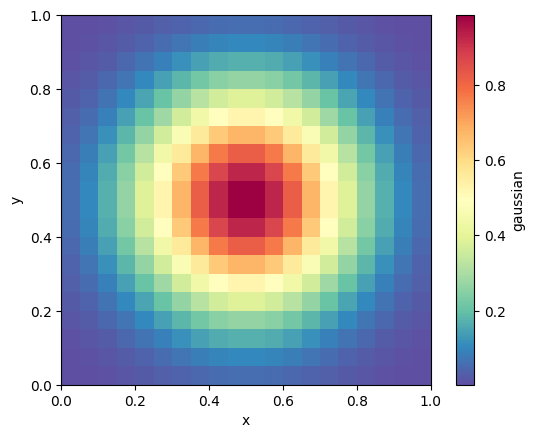

In [17]:
print("sum:", gauss_field.sum())
print("mean:", gauss_field.mean())
print("var:", gauss_field.var())
print("std:", gauss_field.std())
print("min:", gauss_field.min())
print("max:", gauss_field.max())
print("basic statistical summary:", gauss_field.describe())
print("histogram numpy equivalent (counts, edges):", gauss_field.histogram())
print()

gauss_field.plot() # there are many arguments to the plotting function
help(gauss_field.plot)



## IV.3 Use as a numpy array

slicing extensive CartesianField(gaussian@[:, 5], shape=(20,))
slicing extensive CartesianField(gaussian@[:, 2:6], shape=(20, 4))
transpose extensive CartesianField(gaussian, shape=(20, 20))
numpy operation that lose mesh shape or dimension will result in a numpy array:
 <class 'numpy.ndarray'>
 <class 'numpy.ndarray'>
sum along axis 1 extensive CartesianField(gaussian, shape=(20,))
sum along axis 0 extensive CartesianField(gaussian, shape=(20,))
total sum 98.09447081297841
Can manage numpy keepdims arguments: extensive CartesianField(gaussian, shape=(1, 20))


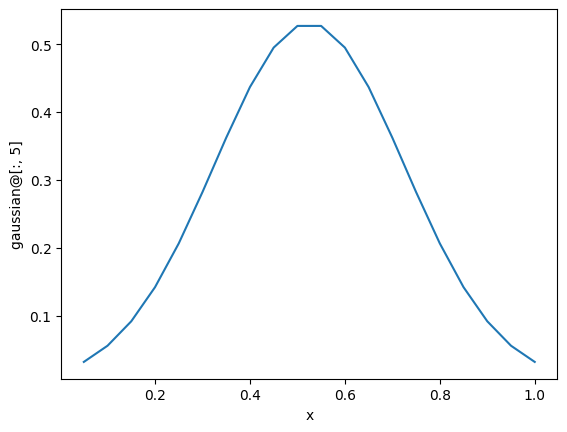

In [18]:
gauss_field *= 2
gauss_field += 2
gauss_field -= 2
gauss_field /= 2

print("slicing", gauss_field[:, 5])
gauss_field[:, 5].plot() # 1D plot
print("slicing", gauss_field[:, 2:6])
print("transpose", gauss_field.transpose())
flatt_array = gauss_field.ravel() # output is a numpy array
print("numpy operation that lose mesh shape or dimension will result in a numpy array:\n", type(flatt_array))

# one can use numpy function instead :
flatt_array = np.ravel(gauss_field)
print("",type(flatt_array))

print("sum along axis 1", np.sum(gauss_field, axis=1))
print("sum along axis 0", np.sum(gauss_field, axis=0))
print("total sum", np.sum(gauss_field))

print("Can manage numpy keepdims arguments:", np.mean(gauss_field, axis=0, keepdims=True))

## IV.4 Operations on field

Let's start with projection, default projection is conservative. It uses cells sizes (volumes) to preserve the overall volume integrated values.
Nonetheless, the project_on methods has a weights argument (either a CartesianField or numpy array) that can be provided by the user to apply a different conservation law.

(20, 20)
(100, 100)
(10, 10)


Text(0.5, 1.0, 'Gaussian coarse')

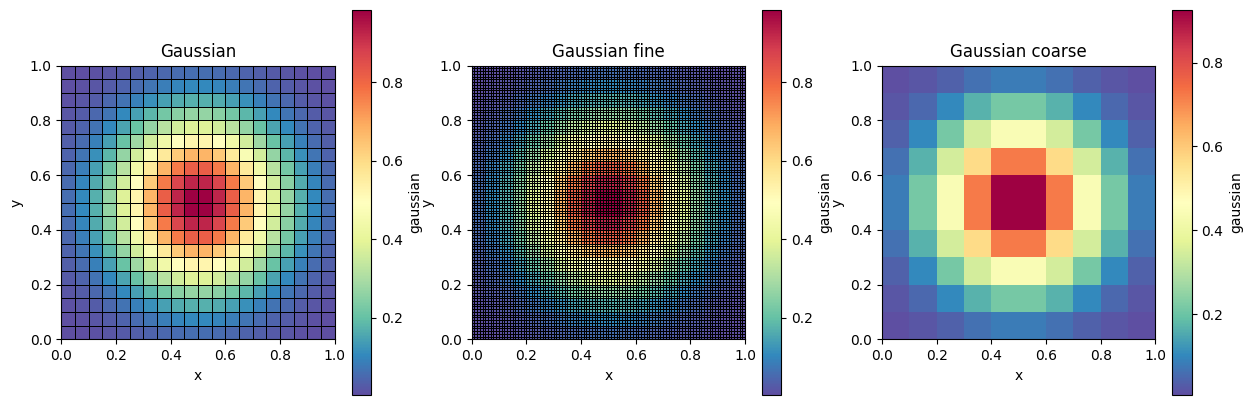

In [19]:
fine_mesh = mesh_2d(nx=100, ny=100, ly=1.0)
coarse_mesh = mesh_2d(nx=10, ny=10, ly=1.0)
print(gauss_field.mesh.shape)
print(fine_mesh.shape)
print(coarse_mesh.shape)

# projection
fine_gauss_field = gauss_field.project_on(fine_mesh)
coarse_gauss_field = gauss_field.project_on(coarse_mesh)
# Plot all three
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
gauss_field.plot(display_edges=True, ax=axes[0])
axes[0].set_title("Gaussian")
fine_gauss_field.plot(display_edges=True, ax=axes[1])
axes[1].set_title("Gaussian fine")
coarse_gauss_field.plot(ax=axes[2])
axes[2].set_title("Gaussian coarse")


Projection can be used with differents dimension meshes, for instance projecting a 3D field onto a 2D mesh will project the 2 first axis and keep the third one at it is.

(10, 10, 20)


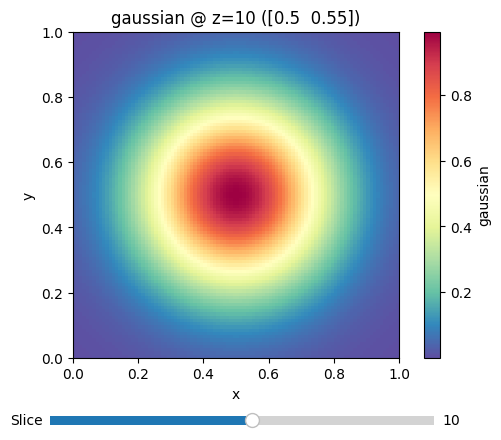

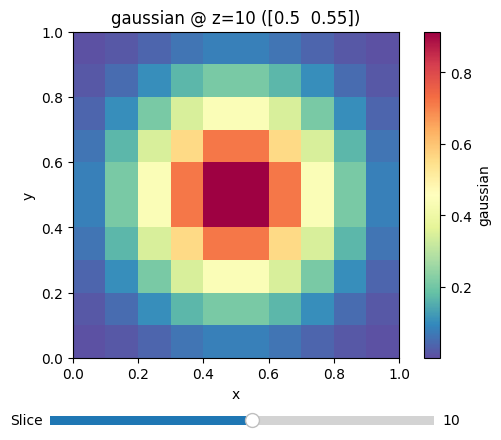

In [20]:
mesh3d = mesh_3d(nx=100, ny=100)
gauss_field_3d = field_gaussian(mesh3d, intensive=False)
gauss_field_3d_proj = gauss_field_3d.project_on(coarse_mesh)
print(gauss_field_3d_proj.shape)

# Plot all 2, 3D plot have a slice to move along the third axis.
gauss_field_3d.plot() 
gauss_field_3d_proj.plot()

# it is equivalent to :
gauss_field_3d_proj = gauss_field_3d.project_on(mesh3d.projected_on(coarse_mesh))
# and for convenience, also equivalent to :
gauss_field_3d_proj = gauss_field_3d.project_on(coarse_gauss_field)
gauss_field_3d_proj = gauss_field_3d.project_on(coarse_gauss_field.mesh)


Rotation by 90 is available through 2 means :

Text(0.5, 1.0, 'Sinusoidal 90°')

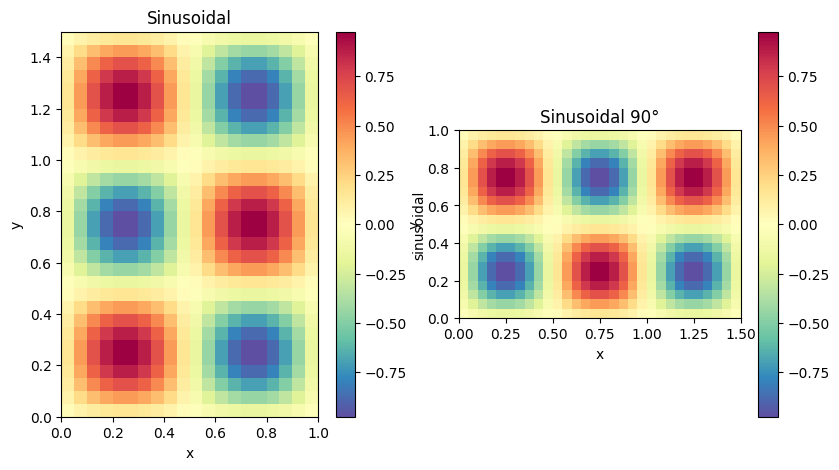

In [21]:
# The rot90 method will rotate both values and mesh :

from numfield import field_sinusoidal
mesh = mesh_2d()
sin_field = field_sinusoidal(mesh)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sin_field.plot(ax=axes[0])
axes[0].set_title("Sinusoidal")
sin_field.rot90(1).plot(ax=axes[1])
axes[1].set_title("Sinusoidal 90°")


Text(0.5, 1.0, 'Sinusoidal 90°')

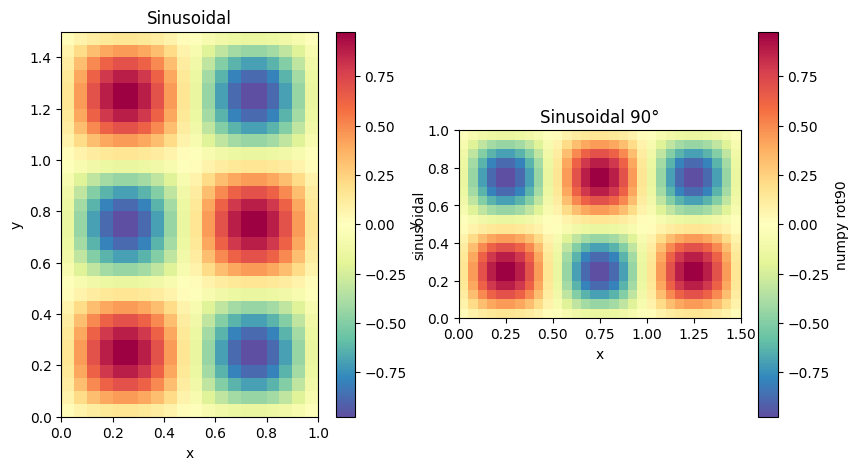

In [22]:
# While the numpy rot90 function will only rotate values and return them as a numpy array, therefore not rotating the mesh :

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sin_field.plot(ax=axes[0])
axes[0].set_title("Sinusoidal")
# the mesh has to be rotated on its own
CartesianField('numpy rot90', sin_field.mesh.rot90(1), np.rot90(sin_field, 1), True).plot(ax=axes[1])
axes[1].set_title("Sinusoidal 90°")